# Tarea 3

Integrantes:
- Romina Loayza
- Nicolás Gutierrez 
- Alfredo Aro

In [367]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm # Import Statsmodels for statistical modeling
from sklearn.linear_model import LinearRegression # Import LinearRegression from scikit-learn for regression analysis
from sklearn.metrics import mean_squared_error, r2_score # Import metrics for model evaluation
from statsmodels.stats.diagnostic import het_breuschpagan, het_white # Import tests for heteroscedasticity
from scipy import stats
from tabulate import tabulate
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 1. Limpieza de data

### Módulo Empleo

In [370]:
csv_path = os.path.join("data", "ENPOVE2022_V_600 Empleo.csv")
m_empleo= pd.read_csv(csv_path,encoding = "latin-1", low_memory=False)
m_empleo.columns= m_empleo.columns.str.lower()
m_empleo

,ï»¿ccdd,departamento,ccpp,provincia,ccdi,distrito,ciudad,conglomerado,nselv,vivienda,...,gedad1,gedad2,p625_d,p625_p,m622_1,m622_2,ingtot,ingtot_monetario,ingtot_no_monetario,factorfinal
0,2,ANCASH,18,SANTA,1,CHIMBOTE,Chimbote,1206802,9340,3,...,2,2,1,1,1600,300,1900,1600,300,13.175820
1,2,ANCASH,18,SANTA,1,CHIMBOTE,Chimbote,1206802,9340,3,...,0,0,,,,,,,,13.175820
2,2,ANCASH,18,SANTA,1,CHIMBOTE,Chimbote,1206802,9340,3,...,3,3,1,1,,,1200,1200,0,13.175820
3,2,ANCASH,18,SANTA,1,CHIMBOTE,Chimbote,1207001,9345,6,...,2,2,1,1,800,300,1100,800,300,26.351641
4,2,ANCASH,18,SANTA,1,CHIMBOTE,Chimbote,1207001,9345,6,...,0,0,,,,,,,,26.351641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11616,24,TUMBES,1,TUMBES,1,TUMBES,Tumbes,44789,393,12,...,2,2,1,1,,,1300,1300,0,18.422158
11617,24,TUMBES,1,TUMBES,1,TUMBES,Tumbes,44789,393,12,...,1,1,1,1,,,1299,1299,0,18.422158
11618,24,TUMBES,1,TUMBES,1,TUMBES,Tumbes,44789,396,13,...,3,3,1,1,,,312,312,0,12.281439
11619,24,TUMBES,1,TUMBES,1,TUMBES,Tumbes,44789,396,13,...,3,4,,,,,,,,12.281439


### Módulo Residentes del Hogar

In [372]:
csv_path = os.path.join("data", "ENPOVE2022_V_200_Residentes.csv")
m_residentes= pd.read_csv(csv_path,encoding = "latin-1", low_memory=False)
m_residentes.columns= m_residentes.columns.str.lower()
m_residentes

,ï»¿ccdd,departamento,ccpp,provincia,ccdi,distrito,ciudad,conglomerado,nselv,vivienda,...,p211_n,p211_1,p200_aportante,p211_n_parentesco,p211_n_sexo,p211_n_aãos,p211_n_meses,p211_n_ecivil,p211_n_migrante,factorfinal
0,15,LIMA,1,LIMA,19,LURIN,Lima,29806,68378,12,...,2,4.Otro,,2,2,29,,1,1,133.030686
1,15,LIMA,1,LIMA,19,LURIN,Lima,29778,68073,9,...,1,4.Otro,,1,2,35,,1,1,133.030686
2,7,LIMA,1,CALLAO,1,CALLAO,Lima,1814802,16137,9,...,1,4.Otro,,1,2,35,,6,1,133.030686
3,14,LAMBAYEQUE,1,CHICLAYO,6,LA VICTORIA,Chiclayo,3976,4564,9,...,1,4.Otro,,1,2,17,,6,1,18.043333
4,2,ANCASH,18,SANTA,1,CHIMBOTE,Chimbote,12284,10250,9,...,5,4.Otro,,11,2,17,,1,1,26.351641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12482,4,AREQUIPA,1,AREQUIPA,7,JACOBO HUNTER,Arequipa,43374,14722,29,...,,,,,,,,,,66.313829
12483,4,AREQUIPA,1,AREQUIPA,7,JACOBO HUNTER,Arequipa,43377,14725,32,...,,,,,,,,,,132.627658
12484,4,AREQUIPA,1,AREQUIPA,7,JACOBO HUNTER,Arequipa,43377,14725,32,...,,,,,,,,,,132.627658
12485,4,AREQUIPA,1,AREQUIPA,7,JACOBO HUNTER,Arequipa,43410,14694,7,...,,,,,,,,,,132.627658


### Merge

In [374]:
columnas_comunes = ['ï»¿ccdd', 'ccpp', 'ccdi', 'conglomerado', 'nselv', 'vivienda', 'thogar', 'nhogar', 'p200_n']
#estas son las columnas comunes entra las dos bases de datos que nos ayudarán a realizar el merge

In [375]:
print("Contenido de las columnas comunes en m_residentes:")
print(m_residentes[columnas_comunes].head())

print("\nContenido de las columnas comunes en m_empleo:")
print(m_empleo[columnas_comunes].head())

Contenido de las columnas comunes en m_residentes:
   ï»¿ccdd  ccpp  ccdi  conglomerado  nselv  vivienda  thogar  nhogar  p200_n
0       15     1    19         29806  68378        12       1       1       5
1       15     1    19         29778  68073         9       1       1       6
2        7     1     1       1814802  16137         9       1       1       5
3       14     1     6          3976   4564         9       1       1       1
4        2    18     1         12284  10250         9       1       1       5

Contenido de las columnas comunes en m_empleo:
   ï»¿ccdd  ccpp  ccdi  conglomerado  nselv  vivienda  thogar  nhogar  p200_n
0        2    18     1       1206802   9340         3       1       1       1
1        2    18     1       1206802   9340         3       1       1       4
2        2    18     1       1206802   9340         3       1       1       5
3        2    18     1       1207001   9345         6       1       1       1
4        2    18     1       1207001   9345

### Creación de código único

In [377]:
m_residentes['codigo_unico'] = m_residentes[columnas_comunes].astype(str).agg('-'.join, axis=1)
m_empleo['codigo_unico'] = m_empleo[columnas_comunes].astype(str).agg('-'.join, axis=1)

In [378]:
for columna in columnas_comunes:
    m_residentes[columna] = m_residentes[columna].astype(str).str.strip()  
    m_empleo[columna] = m_empleo[columna].astype(str).str.strip() 

In [379]:
coincidencias = m_residentes['codigo_unico'].isin(m_empleo['codigo_unico'])
coincidencias

0        True
1        True
2        True
3        True
4        True
         ... 
12482    True
12483    True
12484    True
12485    True
12486    True
Name: codigo_unico, Length: 12487, dtype: bool

In [380]:
#nombramos nuestra data como "venezolanos"
venezolanos = pd.merge(m_residentes, m_empleo, on='codigo_unico', how='inner', suffixes=('_residente', '_empleo'))

In [381]:
columnas_residente = set(venezolanos.filter(regex='_residente').columns)
columnas_empleo = set(venezolanos.filter(regex='_empleo').columns)

In [382]:
for col_residente in columnas_residente:
    # Identificar el nombre base de la columna
    col_base = col_residente.replace('_residente', '')
    col_empleo = col_base + '_empleo'
    
    if col_empleo in columnas_empleo:
        # Priorizar la columna de m_empleo
        venezolanos[col_base] = venezolanos[col_empleo]
        # Eliminar las columnas duplicadas
        venezolanos.drop([col_residente, col_empleo], axis=1, inplace=True)

### **Selección de variables**
- p203: ¿Cuál es la relación de parentesco con el/la jefa del hogar? **[Categórica]**
- p204: Sexo **[Categórica]**
- p205_a: ¿Qué edad tiene en años cumplidos? **[Numérica]**
- p208: ¿Migró de Venezuela? **[Categórica]** - esta variable es más que todo para asegurar que todos hayan dicho que 'sí'
- p613: Usted, ¿ha firmado algún contrato laboral o brindó algún comprobante de pago por sus servicios? **[Categórica]**
- p616a: Normalmente, ¿Cuántas horas trabaja a la semana en todas sus ocupaciones? **[Numérica]**
- p621: En su ocupación principal, ¿la frecuencia con que a usted le pagan es...? **[Categórica]**
- p622_1: ¿Cuánto fue su ingreso total sin descuento en el/la anterior, incluyendo horas extra? **[Numérica]**
- estrato: Estrato social **[Categórica]**
- p636: En Venezuela, ¿tenía usted trabajo antes de iniciar su viaje? **[Categórica]**

In [384]:
variables =['p203','p204', 'p205_a', 'p208', 'p613', 'p621', 'p622_1', 'p636', 'estrato', 'p616a']
venezolanos = venezolanos[variables].copy()
venezolanos.head()

,p203,p204,p205_a,p208,p613,p621,p622_1,p636,estrato,p616a
0,8.Otro pariente,2.Mujer,16,1.SÃ­,,,,2,4,
1,4.Yerno/nuera,2.Mujer,17,1.SÃ­,,,,2,4,
2,4.Yerno/nuera,2.Mujer,17,1.SÃ­,,,,2,3,
3,1.Jefe/a del hogar,2.Mujer,17,1.SÃ­,2,1,30,2,4,
4,11.Otro no pariente,2.Mujer,17,1.SÃ­,,,,2,4,


In [385]:
import warnings
warnings.filterwarnings('ignore')
venezolanos = venezolanos.applymap(lambda x: ''.join(filter(str.isdigit, str(x))))
venezolanos

,p203,p204,p205_a,p208,p613,p621,p622_1,p636,estrato,p616a
0,8,2,16,1,,,,2,4,
1,4,2,17,1,,,,2,4,
2,4,2,17,1,,,,2,3,
3,1,2,17,1,2,1,30,2,4,
4,11,2,17,1,,,,2,4,
...,...,...,...,...,...,...,...,...,...,...
11616,2,2,31,1,2,4,830,2,3,
11617,1,1,30,1,1,2,800,1,4,
11618,2,2,25,1,1,2,300,2,4,
11619,1,1,48,1,2,4,270,1,2,


### Revisamos el tipo de datos

In [387]:
venezolanos.dtypes

p203       object
p204       object
p205_a     object
p208       object
p613       object
p621       object
p622_1     object
p636       object
estrato    object
p616a      object
dtype: object

In [388]:
venezolanos = venezolanos.apply(pd.to_numeric, errors="coerce") 
venezolanos.dropna(inplace=True) 
venezolanos

,p203,p204,p205_a,p208,p613,p621,p622_1,p636,estrato,p616a
14,4,2,17.0,1,2.0,1.0,20.0,1.0,3,8.0
45,1,1,52.0,1,2.0,1.0,80.0,1.0,2,50.0
65,1,2,36.0,1,2.0,2.0,350.0,1.0,3,66.0
82,1,1,48.0,1,2.0,4.0,1000.0,1.0,4,72.0
111,11,1,26.0,1,2.0,2.0,280.0,1.0,3,48.0
...,...,...,...,...,...,...,...,...,...,...
11530,3,2,23.0,1,2.0,4.0,1800.0,1.0,4,48.0
11531,8,1,26.0,1,2.0,2.0,330.0,1.0,4,66.0
11545,1,1,38.0,1,2.0,3.0,650.0,1.0,2,46.0
11567,1,2,46.0,1,2.0,2.0,180.0,1.0,3,66.0


### Creamos una nueva variable con el monto mensual de ingresos

In [390]:
# Diccionario con los multiplicadores de frecuencia
multiplicadores = {
    1: 30,  # Diario
    2: 4,   # Semanal
    3: 2,   # Quincenal
    4: 1    # Mensual
}

# Calcular el ingreso mensual usando el diccionario
venezolanos['ingreso_mensual'] = venezolanos['p622_1'] * venezolanos['p621'].map(multiplicadores)
# Creamos una nueva columna para el logaritmo del ingreso mensual
venezolanos['log_ingreso_mensual'] = venezolanos['ingreso_mensual'].apply(lambda x: np.log(x) if x > 0 else np.nan)

# Calcular las horas de trabajo mensual
venezolanos['horas_mensual'] = venezolanos['p616a'] *4
venezolanos

,p203,p204,p205_a,p208,p613,p621,p622_1,p636,estrato,p616a,ingreso_mensual,log_ingreso_mensual,horas_mensual
14,4,2,17.0,1,2.0,1.0,20.0,1.0,3,8.0,600.0,6.396930,32.0
45,1,1,52.0,1,2.0,1.0,80.0,1.0,2,50.0,2400.0,7.783224,200.0
65,1,2,36.0,1,2.0,2.0,350.0,1.0,3,66.0,1400.0,7.244228,264.0
82,1,1,48.0,1,2.0,4.0,1000.0,1.0,4,72.0,1000.0,6.907755,288.0
111,11,1,26.0,1,2.0,2.0,280.0,1.0,3,48.0,1120.0,7.021084,192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11530,3,2,23.0,1,2.0,4.0,1800.0,1.0,4,48.0,1800.0,7.495542,192.0
11531,8,1,26.0,1,2.0,2.0,330.0,1.0,4,66.0,1320.0,7.185387,264.0
11545,1,1,38.0,1,2.0,3.0,650.0,1.0,2,46.0,1300.0,7.170120,184.0
11567,1,2,46.0,1,2.0,2.0,180.0,1.0,3,66.0,720.0,6.579251,264.0


In [391]:
venezolanos['p208'] = venezolanos['p208'].apply(lambda x: 0 if x == 2 else 1)

venezolanos['p613'] = venezolanos['p613'].apply(lambda x: 0 if x == 2 else 1)

venezolanos['p636'] = venezolanos['p636'].apply(lambda x: 0 if x == 2 else 1)

### Renombramos

In [393]:
venezolanos.rename(columns={
    'p203': 'jefe_hogar',
    'p204': 'sexo',
    'p205_a': 'edad',
    'p208': 'migracion_venezuela',
    'p613': 'firma_contrato',
    'p636': 'trabajo_venezuela',
}, inplace=True)
venezolanos

,jefe_hogar,sexo,edad,migracion_venezuela,firma_contrato,p621,p622_1,trabajo_venezuela,estrato,p616a,ingreso_mensual,log_ingreso_mensual,horas_mensual
14,4,2,17.0,1,0,1.0,20.0,1,3,8.0,600.0,6.396930,32.0
45,1,1,52.0,1,0,1.0,80.0,1,2,50.0,2400.0,7.783224,200.0
65,1,2,36.0,1,0,2.0,350.0,1,3,66.0,1400.0,7.244228,264.0
82,1,1,48.0,1,0,4.0,1000.0,1,4,72.0,1000.0,6.907755,288.0
111,11,1,26.0,1,0,2.0,280.0,1,3,48.0,1120.0,7.021084,192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11530,3,2,23.0,1,0,4.0,1800.0,1,4,48.0,1800.0,7.495542,192.0
11531,8,1,26.0,1,0,2.0,330.0,1,4,66.0,1320.0,7.185387,264.0
11545,1,1,38.0,1,0,3.0,650.0,1,2,46.0,1300.0,7.170120,184.0
11567,1,2,46.0,1,0,2.0,180.0,1,3,66.0,720.0,6.579251,264.0


### Nos quedamos con las variables que necesitamos

In [395]:
venezolanos = venezolanos[['jefe_hogar', 'sexo', 'edad', 'firma_contrato', 'migracion_venezuela', 'trabajo_venezuela', 'estrato', 'ingreso_mensual', 'log_ingreso_mensual', 'horas_mensual']]
venezolanos.head()

,jefe_hogar,sexo,edad,firma_contrato,migracion_venezuela,trabajo_venezuela,estrato,ingreso_mensual,log_ingreso_mensual,horas_mensual
14,4,2,17.0,0,1,1,3,600.0,6.396930,32.0
45,1,1,52.0,0,1,1,2,2400.0,7.783224,200.0
65,1,2,36.0,0,1,1,3,1400.0,7.244228,264.0
82,1,1,48.0,0,1,1,4,1000.0,6.907755,288.0
111,11,1,26.0,0,1,1,3,1120.0,7.021084,192.0


In [396]:
venezolanos.shape

(468, 10)

### Descargamos nuestra data

In [398]:
venezolanos.to_csv("venezolanos.csv", index=False)

## 2. Creación de variable dicotómica

En nuestro caso nos encontramos empleando la variable "ingreso_mensual" como dependiente, por lo que para convertirla a una variable dicotómica la empleamos en función del sueldo mínimo peruano hasta el momento en el que se recogió información del censo (Febrero - 2022). 

La observación asume un valor de 0 en la columna "mas_minimo" si es que recibió un monto inferior al sueldo minímo nacional y un valor de 1 si es que recibió un valor mayor o igual.

In [401]:
venezolanos["mas_minimo"] = venezolanos["ingreso_mensual"].apply(lambda x: 1 if x >= 930 else 0)
venezolanos

,jefe_hogar,sexo,edad,firma_contrato,migracion_venezuela,trabajo_venezuela,estrato,ingreso_mensual,log_ingreso_mensual,horas_mensual,mas_minimo
14,4,2,17.0,0,1,1,3,600.0,6.396930,32.0,0
45,1,1,52.0,0,1,1,2,2400.0,7.783224,200.0,1
65,1,2,36.0,0,1,1,3,1400.0,7.244228,264.0,1
82,1,1,48.0,0,1,1,4,1000.0,6.907755,288.0,1
111,11,1,26.0,0,1,1,3,1120.0,7.021084,192.0,1
...,...,...,...,...,...,...,...,...,...,...,...
11530,3,2,23.0,0,1,1,4,1800.0,7.495542,192.0,1
11531,8,1,26.0,0,1,1,4,1320.0,7.185387,264.0,1
11545,1,1,38.0,0,1,1,2,1300.0,7.170120,184.0,1
11567,1,2,46.0,0,1,1,3,720.0,6.579251,264.0,0


In [402]:
#revisamos el tipo de nuestra data
venezolanos.dtypes

jefe_hogar               int64
sexo                     int64
edad                   float64
firma_contrato           int64
migracion_venezuela      int64
trabajo_venezuela        int64
estrato                  int64
ingreso_mensual        float64
log_ingreso_mensual    float64
horas_mensual          float64
mas_minimo               int64
dtype: object

In [403]:
#transformamos a categóricas nuestras variables
venezolanos['sexo'] = venezolanos['sexo'].astype('category')
venezolanos['estrato'] = venezolanos['estrato'].astype('category')

venezolanos['sexo'] = venezolanos['sexo'].cat.rename_categories({1: 'Hombre', 2: 'Mujer'})
venezolanos['estrato'] = venezolanos['estrato'].cat.rename_categories({1: 'Bajo', 2: 'Medio-Bajo', 3: 'Medio', 4: 'Medio-Alto', 5: 'Alto'})

venezolanos = pd.get_dummies(venezolanos, columns=['estrato', 'sexo'], drop_first=False)
venezolanos = venezolanos.fillna(0).astype(int)

venezolanos.head()

,jefe_hogar,edad,firma_contrato,migracion_venezuela,trabajo_venezuela,ingreso_mensual,log_ingreso_mensual,horas_mensual,mas_minimo,estrato_Bajo,estrato_Medio-Bajo,estrato_Medio,estrato_Medio-Alto,estrato_Alto,sexo_Hombre,sexo_Mujer
14,4,17,0,1,1,600,6,32,0,0,0,1,0,0,0,1
45,1,52,0,1,1,2400,7,200,1,0,1,0,0,0,1,0
65,1,36,0,1,1,1400,7,264,1,0,0,1,0,0,0,1
82,1,48,0,1,1,1000,6,288,1,0,0,0,1,0,1,0
111,11,26,0,1,1,1120,7,192,1,0,0,1,0,0,1,0


In [404]:
venezolanos.shape

(468, 16)

## 3. Regresión Logística

In [429]:
y = venezolanos['mas_minimo']  
X = venezolanos[['horas_mensual', 'trabajo_venezuela', 'firma_contrato', 'edad', 'sexo_Mujer', 'estrato_Alto']]  

X = sm.add_constant(X)

# Modelo Logit
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.588173
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             mas_minimo   No. Observations:                  468
Model:                          Logit   Df Residuals:                      461
Method:                           MLE   Df Model:                            6
Date:                Tue, 11 Feb 2025   Pseudo R-squ.:                 0.07808
Time:                        21:21:10   Log-Likelihood:                -275.26
converged:                       True   LL-Null:                       -298.58
Covariance Type:            nonrobust   LLR p-value:                 2.223e-08
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.8668      0.497     -1.744      0.081      -1.841       0.107
horas_me

### Interpretación


- Trabajar más horas al mes está asociado significativamente a una mayor probabilidad de ganar al menos 930. 

- Haber trabajado antes en su país no está asociado significativamente con la probabilidad de ganar el sueldo m-ínimo o más.

- Tener un contrato formal está asociado significativamente a una mayor probabilidad de ganar al menos 930. 

- Ser mayor no está asociado significativamente a una mayor probabilidad de ganar más del sueldo mínimo.

- Ser mujer está asociado significativamente a una menor probabilidad de ganar al menos 930 soles al mes. 

- Pertenecer a un estrato alto está asociado significativamente con una menor probabilidad de ganar el sueldo mínimo o más.

### 3.1. Efectos Marginales

#### 3.1.1. Efectos Marginales en la media de las variables

In [446]:
marginal_effects = logit_model.get_margeff(method="dydx", at="mean")  
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:             mas_minimo
Method:                          dydx
At:                              mean
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
horas_mensual         0.0010      0.000      3.315      0.001       0.000       0.002
trabajo_venezuela     0.0707      0.054      1.308      0.191      -0.035       0.177
firma_contrato        0.2807      0.083      3.386      0.001       0.118       0.443
edad                  0.0038      0.002      1.599      0.110      -0.001       0.008
sexo_Mujer           -0.1454      0.047     -3.126      0.002      -0.236      -0.054
estrato_Alto         -0.1990      0.093     -2.138      0.032      -0.381      -0.017


#### Interpretación

- Trabajar más horas al mes está asociado significativamente a una mayor probabilidad de ganar al menos 930. Cada hora adicional trabajada aumenta la probabilidad en 0.10 puntos porcentuales. - Trabajar en Venezuela no está asociado significativamente con la probabilidad de ganar al menos 930. - Tener un contrato formal está asociado significativamente a una mayor probabilidad de ganar el sueldo mínimo o más. Tener un contrato aumenta la probabilidad en 28.07 puntos porcentuales. - Ser mayor está asociado significativamente a una mayor probabilidad de ganar al menos 930. Cada año adicional de edad aumenta la probabilidad en 0.38 puntos porcentuales. - Ser mujer está asociado significativamente a una menor probabilidad de ganar el sueldo mínimo o más. Se reduce la probabilidad en 14.54 puntos porcentuales. - Pertenecer a un estrato alto está asociado significativamente a una menor probabilidad de ganar al menos 930. Disminuye la probabilidad en 19.90 puntos porcentuales.

#### 3.1.2. Efectos Marginales en el promedio de toda la muestra

In [448]:
marginal_overall = logit_model.get_margeff(method="dydx", at="overall")
print(marginal_overall.summary())

        Logit Marginal Effects       
Dep. Variable:             mas_minimo
Method:                          dydx
At:                           overall
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
horas_mensual         0.0009      0.000      3.457      0.001       0.000       0.001
trabajo_venezuela     0.0656      0.050      1.317      0.188      -0.032       0.163
firma_contrato        0.2606      0.075      3.456      0.001       0.113       0.408
edad                  0.0035      0.002      1.612      0.107      -0.001       0.008
sexo_Mujer           -0.1349      0.042     -3.232      0.001      -0.217      -0.053
estrato_Alto         -0.1847      0.085     -2.177      0.029      -0.351      -0.018


#### Interpretación

- Trabajar más horas al mes está asociado significativamente a una mayor probabilidad de ganar al menos 930. Cada hora adicional trabajada aumenta la probabilidad en 0.09 puntos porcentuales. - Trabajar en Venezuela no está asociado significativamente con la probabilidad de ganar el sueldo mínimo o más.- Tener un contrato formal está asociado significativamente a una mayor probabilidad de ganar al menos 930. Tener un contrato aumenta la probabilidad en 26.06 puntos porcentuales. - Ser mayor no está asociado significativamente a una mayor probabilidad. - Ser mujer está asociado significativamente a una menor probabilidad de ganar al menos 930. Se reduce la probabilidad en 13.49 puntos porcentuales. - Pertenecer a un estrato alto está asociado significativamente a una menor probabilidad de ganar por lo menos el sueldo mínimo. Disminuye la probabilidad en 18.47 puntos porcentuales.

### 3.2. LOG ODDS

In [455]:
log_odds = logit_model.params
print("Log-Odds (Coeficientes en escala logit):")
print(log_odds)

Log-Odds (Coeficientes en escala logit):
const               -0.866760
horas_mensual        0.004712
trabajo_venezuela    0.325801
firma_contrato       1.294601
edad                 0.017475
sexo_Mujer          -0.670258
estrato_Alto        -0.917499
dtype: float64


### 3.3. ODDS Ratio

In [458]:
#odds ratio
odds_ratios = np.exp(logit_model.params)
print("Odds Ratios:")
print(odds_ratios)

Odds Ratios:
const                0.420311
horas_mensual        1.004723
trabajo_venezuela    1.385140
firma_contrato       3.649538
edad                 1.017629
sexo_Mujer           0.511577
estrato_Alto         0.399517
dtype: float64


### 3.4. Obtener prediccions de probabilidad

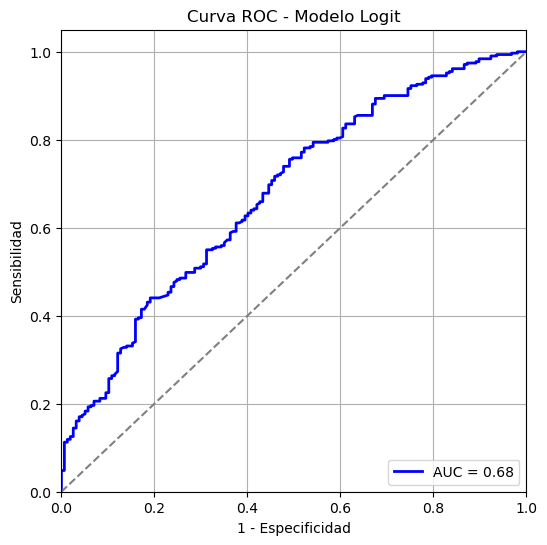

In [463]:
from sklearn.metrics import roc_curve, auc

y_pred_prob = logit_model.predict(X)

# Calcular valores para la curva ROC
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar la curva ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea diagonal (modelo aleatorio)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Especificidad')
plt.ylabel('Sensibilidad')
plt.title('Curva ROC - Modelo Logit')
plt.legend(loc='lower right')
plt.grid()
plt.show()

La curva ROC muestra que el modelo Logit tiene una capacidad de predicción baja (AUC = 0.68), lo que sugiere que no es muy efectivo en diferenciar personas de origen venezolano que ganan o no el sueldo mínimo.

### 3.5. Poder Preditivo

In [472]:
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Elegir un umbral de clasificación
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

# Calcular la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
# tn: true negatives
# fp: falsos positivos
# fn: false negatives
# tp: true positives

# Calcular sensibilidad y especificidad
sensibilidad = tp / (tp + fn)  # Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)
especificidad = tn / (tn + fp)  # Verdaderos Negativos / (Verdaderos Negativos + Falsos Positivos)

print(f"Sensibilidad (TPR): {sensibilidad:.2f}")
print(f"Especificidad (TNR): {especificidad:.2f}")

Sensibilidad (TPR): 0.90
Especificidad (TNR): 0.25


Sensibilidad (TPR, True Positive Rate): Mide la capacidad del modelo para identificar correctamente los casos positivos (sueldo mínimo sí: 1).

* Muy alta capacidad del modelo para detectar si las personas ganan el sueldo mínimo. El 90% de los venezolanos que ganan sueldo mínimo fueron correctamente identificados.

Especificidad (TNR, True Negative Rate): Mide la capacidad del modelo para identificar correctamente los casos negativos (sueldo mínimo no: 2).

* Baja capacidad para identificar venezolanos que no ganan el sueldo mínimo. El modelo clasifica correctamente solo el 25% de los venezolanos que no ganan sueldo mínimo fueron correctamente identificados.

## 4. Modelo Probit

In [476]:
# Definir las variables independientes
X = venezolanos[['horas_mensual', 'trabajo_venezuela', 'firma_contrato', 'edad', 'sexo_Mujer', 'estrato_Alto']]
# Agregar la constante al modelo
X = sm.add_constant(X)
# Variable dependiente (anemia)
y = venezolanos['mas_minimo']

# Modelo Logit
probit_model = sm.Probit(y, X).fit()
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.587848
         Iterations 5
                          Probit Regression Results                           
Dep. Variable:             mas_minimo   No. Observations:                  468
Model:                         Probit   Df Residuals:                      461
Method:                           MLE   Df Model:                            6
Date:                Tue, 11 Feb 2025   Pseudo R-squ.:                 0.07859
Time:                        21:50:41   Log-Likelihood:                -275.11
converged:                       True   LL-Null:                       -298.58
Covariance Type:            nonrobust   LLR p-value:                 1.934e-08
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.5393      0.301     -1.792      0.073      -1.129       0.050
horas_me

### Interpretación

### 4.1. Efectos Marginales

#### 4.1.1. Efectos marginales en la media de las variables

In [482]:
marginal_effects = probit_model.get_margeff(method="dydx", at="mean")  
print(marginal_effects.summary())

       Probit Marginal Effects       
Dep. Variable:             mas_minimo
Method:                          dydx
At:                              mean
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
horas_mensual         0.0010      0.000      3.343      0.001       0.000       0.002
trabajo_venezuela     0.0707      0.054      1.299      0.194      -0.036       0.178
firma_contrato        0.2761      0.077      3.569      0.000       0.124       0.428
edad                  0.0039      0.002      1.669      0.095      -0.001       0.009
sexo_Mujer           -0.1458      0.047     -3.126      0.002      -0.237      -0.054
estrato_Alto         -0.2030      0.096     -2.124      0.034      -0.390      -0.016


#### 4.1.2. Efectos marginales promedio en toda la muestra

In [485]:
marginal_overall = probit_model.get_margeff(method="dydx", at="overall")
print(marginal_overall.summary())

       Probit Marginal Effects       
Dep. Variable:             mas_minimo
Method:                          dydx
At:                           overall
                       dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
horas_mensual         0.0010      0.000      3.463      0.001       0.000       0.002
trabajo_venezuela     0.0659      0.050      1.306      0.192      -0.033       0.165
firma_contrato        0.2574      0.070      3.672      0.000       0.120       0.395
edad                  0.0037      0.002      1.683      0.092      -0.001       0.008
sexo_Mujer           -0.1359      0.042     -3.218      0.001      -0.219      -0.053
estrato_Alto         -0.1892      0.088     -2.157      0.031      -0.361      -0.017


### 4.2. Preddciones de probabilidad

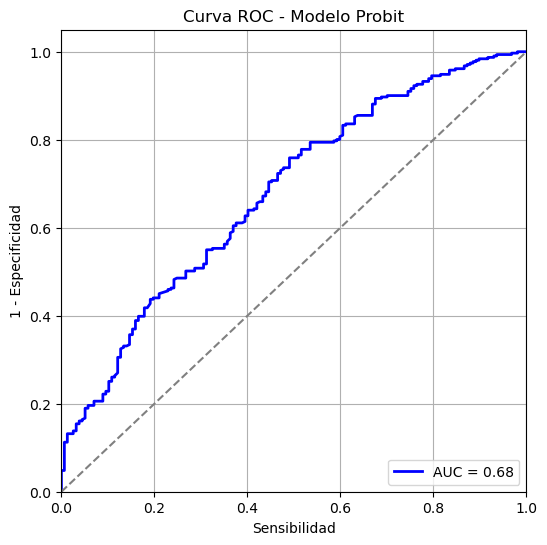

In [488]:
y_pred_prob = probit_model.predict(X)

# Calcular valores para la curva ROC
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar la curva ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea diagonal (modelo aleatorio)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Sensibilidad')
plt.ylabel('1 - Especificidad')
plt.title('Curva ROC - Modelo Probit')
plt.legend(loc='lower right')
plt.grid()
plt.show()

### 4.3. Poder Predictivo

In [504]:
# Elegir un umbral de clasificación
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

# Calcular la matriz de confusión
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
# tn: true negatives
# fp: falsos positivos
# fn: false negatives
# tp: true positives

# Calcular sensibilidad y especificidad
sensibilidad = tp / (tp + fn)  # Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)
especificidad = tn / (tn + fp)  # Verdaderos Negativos / (Verdaderos Negativos + Falsos Positivos)

print(f"Sensibilidad (TPR): {sensibilidad:.2f}")
print(f"Especificidad (TNR): {especificidad:.2f}")

Sensibilidad (TPR): 0.90
Especificidad (TNR): 0.25


In [506]:
lpm_model = sm.OLS(y, X).fit()
lpm_preds = lpm_model.predict(X)  # Predicciones del LPM

# Modelo Logit
logit_model = sm.Logit(y, X).fit()
logit_preds = logit_model.predict(X)  # Predicciones del modelo Logit

# Modelo Probit
probit_model = sm.Probit(y, X).fit()
probit_preds = probit_model.predict(X)  # Predicciones del modelo Probit

predictions = pd.DataFrame({
    'LPM': lpm_preds,
    'Logit': logit_preds,
    'Probit': probit_preds
})

Optimization terminated successfully.
         Current function value: 0.588173
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.587848
         Iterations 5


In [508]:
# Tabla descriptiva de las predicciones
descriptive_table = predictions.describe()

# Mostrar la tabla
print(descriptive_table)

              LPM       Logit      Probit
count  468.000000  468.000000  468.000000
mean     0.664530    0.664530    0.664476
std      0.145547    0.147129    0.147834
min      0.267711    0.244321    0.243295
25%      0.571295    0.574349    0.571929
50%      0.678485    0.690070    0.686745
75%      0.760731    0.769485    0.769430
max      1.091704    0.952181    0.965010


## 5. Comparación

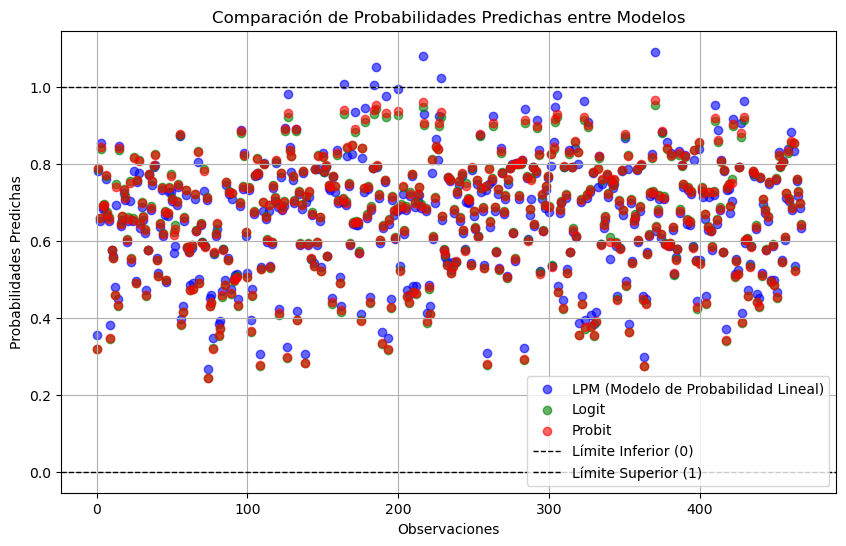

In [511]:
# Gráfico de comparación
plt.figure(figsize=(10, 6))

# Predicciones del LPM
plt.scatter(range(len(lpm_preds)), lpm_preds, color='blue', alpha=0.6, label='LPM (Modelo de Probabilidad Lineal)')

# Predicciones del Logit
plt.scatter(range(len(logit_preds)), logit_preds, color='green', alpha=0.6, label='Logit')

# Predicciones del Probit
plt.scatter(range(len(probit_preds)), probit_preds, color='red', alpha=0.6, label='Probit')

# Límites de 0 y 1
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Límite Inferior (0)')
plt.axhline(y=1, color='black', linestyle='--', linewidth=1, label='Límite Superior (1)')

# Configuración del gráfico
plt.title('Comparación de Probabilidades Predichas entre Modelos')
plt.xlabel('Observaciones')
plt.ylabel('Probabilidades Predichas')
plt.legend()
plt.grid()
plt.show()